[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benchuangxd/CSC3109-T16-Project/blob/main/notebooks/02_custom_cnn.ipynb)

# Custom CNN

**CSC3109 - Machine Learning | Team 16 — Member 1**

In [1]:
# ── Google Colab Setup ──────────────────────────────────────────────────────
# Run this cell first when using Google Colab. No effect when running locally.
import sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    from pathlib import Path

    REPO_URL  = "https://github.com/benchuangxd/CSC3109-T16-Project.git"
    REPO_PATH = Path("/content/CSC3109-T16-Project")

    if not REPO_PATH.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_PATH)], check=True)
    else:
        print(f"Repo already exists at {REPO_PATH}")

    %cd /content/CSC3109-T16-Project
    %pip install -q -r requirements.txt
    print("Colab setup complete.")
else:
    print("Running locally — skipping Colab setup.")

/content/CSC3109-T16-Project
Colab setup complete.


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.config import DATA_DIR, CLASS_NAMES, NUM_CLASSES, IMAGE_SIZE, BATCH_SIZE, NUM_EPOCHS, SEED, TRAIN_RATIO
from src.utils import set_seed, get_device

set_seed(SEED)
DEVICE = get_device()
print(f"ROOT   : {ROOT}")
print(f"Device : {DEVICE}")
print(f"Classes: {CLASS_NAMES}")
print(f"Split  : {TRAIN_RATIO:.0%} train / {1-TRAIN_RATIO:.0%} val")
print("Policy : 70/30 split inside each class folder in data/set 16")

ROOT   : /content/CSC3109-T16-Project
Device : cuda
Classes: ['beach', 'ferry_terminal', 'harbor', 'river']
Split  : 70% train / 30% val
Policy : 70/30 split inside each class folder in data/set 16


## **1. Data Loading**
The dataset is loaded using the shared `get_dataloaders()` function from `src.dataset`.
A deterministic 70/30 split is applied inside each class folder in `data/set 16`, giving 1960 training images and 840 validation images across four classes: beach, ferry_terminal, harbor, and river.



In [17]:
from src.dataset import get_dataloaders

train_loader, val_loader, class_names = get_dataloaders(
    root=ROOT,
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    train_ratio=TRAIN_RATIO,
    seed=SEED,
    num_workers=2
)

print("Classes:", class_names)
print("Train images:", len(train_loader.dataset))
print("Val images:", len(val_loader.dataset))

Classes: ['beach', 'ferry_terminal', 'harbor', 'river']
Train images: 1960
Val images: 840


## **2. Model Setup**
This notebook uses a Custom CNN trained from scratch.
The architecture contains convolutional blocks with BatchNorm, ReLU, MaxPool, and Dropout.
The final classifier maps the extracted image features into four aerial-image classes.

In [18]:
import torch
import torch.optim as optim

from src.models import get_custom_cnn
from src.train import train
from src.evaluate import get_predictions, compute_metrics, print_report, plot_confusion_matrix
from src.utils import count_parameters, plot_training_curves, save_metrics_to_csv

model = get_custom_cnn(num_classes=NUM_CLASSES).to(DEVICE)

print(model)
print("Trainable parameters:", count_parameters(model))

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## **3. Training**
The Custom CNN is trained using the Adam optimizer with weight decay and a StepLR learning-rate scheduler.
The best model is saved based on validation accuracy to `results/saved_models/custom_cnn.pth`.

In [19]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)

save_model_path = ROOT / "results" / "saved_models" / "custom_cnn.pth"

history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    save_path=save_model_path
)

print("Training done.")
print("Best model saved to:", save_model_path)

Epoch [01/20]  train loss: 0.7148  train acc: 0.7194  val loss: 0.6273  val acc: 0.7762  (14.2s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/custom_cnn.pth  (val_acc=0.7762)
Epoch [02/20]  train loss: 0.4950  train acc: 0.8117  val loss: 0.2375  val acc: 0.9357  (14.5s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/custom_cnn.pth  (val_acc=0.9357)
Epoch [03/20]  train loss: 0.4165  train acc: 0.8423  val loss: 1.1662  val acc: 0.7012  (14.7s)
Epoch [04/20]  train loss: 0.4066  train acc: 0.8393  val loss: 0.2519  val acc: 0.8988  (14.2s)
Epoch [05/20]  train loss: 0.4174  train acc: 0.8418  val loss: 0.1628  val acc: 0.9405  (13.9s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/custom_cnn.pth  (val_acc=0.9405)
Epoch [06/20]  train loss: 0.3483  train acc: 0.8663  val loss: 0.1707  val acc: 0.9369  (14.2s)
Epoch [07/20]  train loss: 0.3588  train acc: 0.8673  val loss: 0.1663  val acc: 0.9321  (15.1

## **4. Training Curves**

The training and validation loss/accuracy curves are plotted and saved to `results/training_curves`.






Training curves saved to /content/CSC3109-T16-Project/results/training_curves/custom_cnn_training_curve.png


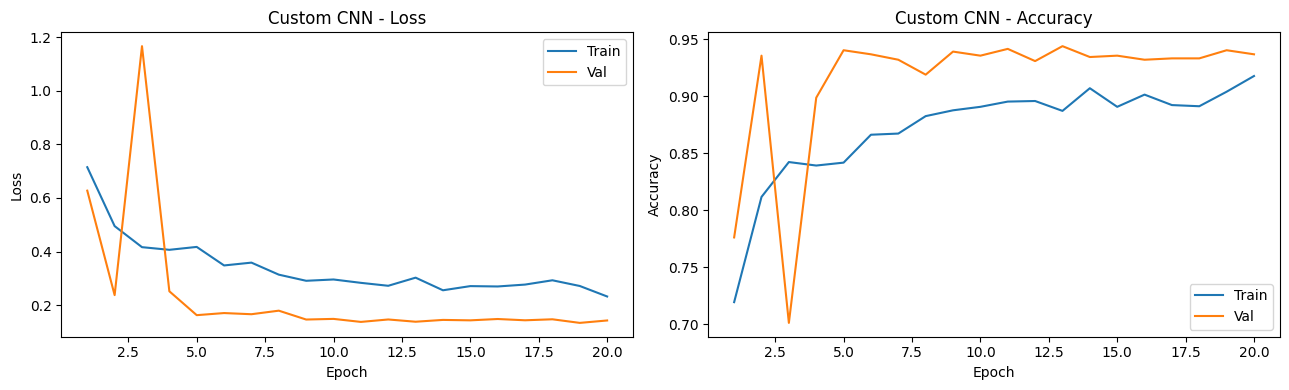

Saved training curve to: /content/CSC3109-T16-Project/results/training_curves/custom_cnn_training_curve.png


In [20]:
curve_path = ROOT / "results" / "training_curves" / "custom_cnn_training_curve.png"

plot_training_curves(
    history,
    title="Custom CNN",
    save_path=curve_path
)

print("Saved training curve to:", curve_path)

## **5. Evaluation**

The best saved Custom CNN model is loaded before evaluation.
The notebook computes accuracy, precision, recall, and F1-score on the validation set.


In [21]:
model = get_custom_cnn(num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(save_model_path, map_location=DEVICE))
model = model.to(DEVICE)

y_pred, y_true = get_predictions(model, val_loader, DEVICE)

metrics = compute_metrics(y_true, y_pred)

print("Custom CNN Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

print("\nClassification Report:")
print_report(y_true, y_pred, class_names)

Custom CNN Metrics:
accuracy: 0.9440
precision: 0.9491
recall: 0.9440
f1_score: 0.9424

Classification Report:
                precision    recall  f1-score   support

         beach       0.96      1.00      0.98       210
ferry_terminal       0.99      0.79      0.88       210
        harbor       0.86      1.00      0.92       210
         river       0.99      1.00      0.99       210

      accuracy                           0.94       840
     macro avg       0.95      0.94      0.94       840
  weighted avg       0.95      0.94      0.94       840



## **6. Confusion Matrix**

A confusion matrix is generated to show which aerial-image classes are correctly classified and which classes are confused.

Confusion matrix saved to /content/CSC3109-T16-Project/results/confusion_matrices/custom_cnn_confusion_matrix.png


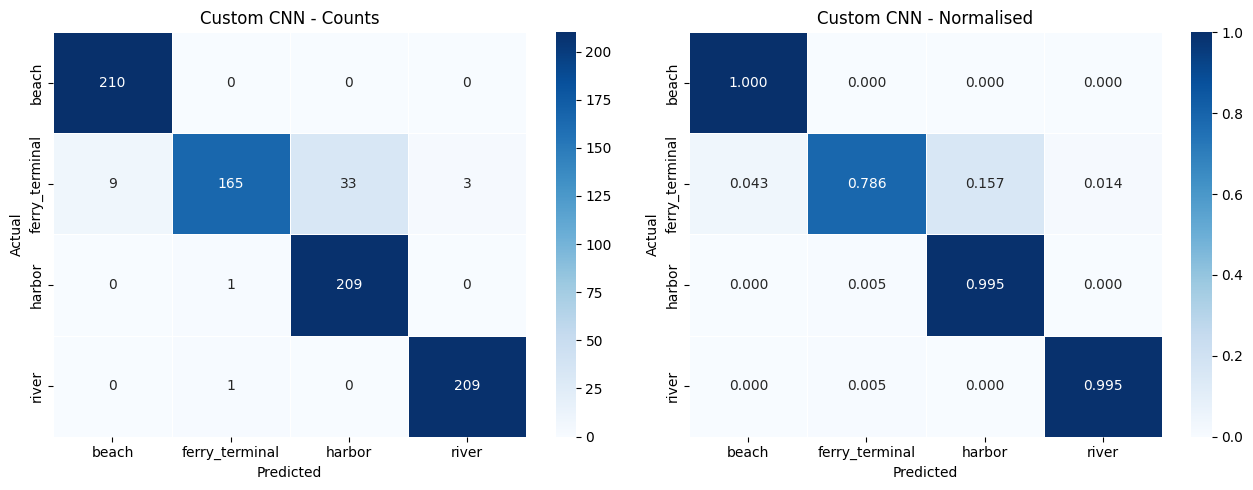

Saved confusion matrix to: /content/CSC3109-T16-Project/results/confusion_matrices/custom_cnn_confusion_matrix.png


In [22]:
cm_path = ROOT / "results" / "confusion_matrices" / "custom_cnn_confusion_matrix.png"

plot_confusion_matrix(
    y_true=y_true,
    y_pred=y_pred,
    class_names=class_names,
    title="Custom CNN",
    save_path=cm_path
)

print("Saved confusion matrix to:", cm_path)


## **7. Save Metrics**

The final Custom CNN metrics are saved into `results/metrics.csv` so that they can be compared with other team members' models.

In [24]:
metrics_path = ROOT / "results" / "metrics.csv"

save_metrics_to_csv(
    model_name="custom_cnn",
    metrics=metrics,
    csv_path=metrics_path
)

print("Saved metrics to:", metrics_path)

Metrics saved to /content/CSC3109-T16-Project/results/metrics.csv
Saved metrics to: /content/CSC3109-T16-Project/results/metrics.csv
